In [ ]:
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import statistics as stats
import os
import pandas as pd

In [ ]:
nRowsRead = 1000 # specify 'None' if want to read whole file
# data.csv may have more rows in reality, but we are only loading/previewing the first 1000 rows
file_url = 'https://raw.githubusercontent.com/luicamongi/Anexo_Magdalena/main/Anexo_nitratos_prom.csv'
df = pd.read_csv(file_url, delimiter=',', nrows=nRowsRead)
df.dataframeName = 'data.csv'
nRow, nCol = df.shape
print(f'There are {nRow} rows and {nCol} columns')

There are 168 rows and 12 columns


In [ ]:
df.head(5)

,Nombre punto de monitoreo,fecha de monitoreo,código de muestra,Oxígeno Disuelto mg O2/L,Temperatura °C,Conductividad Eléctrica uS/cm,Demanda Química de Oxígeno mg/L,pH unidades de pH,Sólidos Suspendidos Totales mg/L,Nitrógeno Total mg /L,Fósforo Total mg/L,Nitratos (mg N-NO3-/L)
0,RCA_MAGDALENA_HUI_GIGANTE_PASO DEL COLEGIO [21...,30/03/2009,17398,6.1,22.0,128.0,31.0,7.84,680.0,1.00,0.930,0.240
1,RCA_MAGDALENA_HUI_GIGANTE_PASO DEL COLEGIO [21...,4/06/2009,17629,7.2,21.4,102.0,58.0,7.76,1090.0,0.53,1.800,0.550
2,RCA_MAGDALENA_HUI_GIGANTE_PASO DEL COLEGIO [21...,19/06/2009,17688,7.9,24.1,120.3,20.0,6.61,200.0,0.61,0.530,0.295
3,RCA_MAGDALENA_HUI_GIGANTE_PASO DEL COLEGIO [21...,11/09/2009,17842,7.5,23.5,111.0,27.0,7.37,38.0,0.50,0.140,0.068
4,RCA_MAGDALENA_HUI_GIGANTE_PASO DEL COLEGIO [21...,31/10/2009,18197,7.8,25.5,199.0,110.0,7.19,1380.0,3.50,0.076,0.250


In [ ]:
df.isna() .sum()

,0
Nombre punto de monitoreo,0
fecha de monitoreo,0
código de muestra,0
Oxígeno Disuelto mg O2/L,1
Temperatura °C,0
Conductividad Eléctrica uS/cm,2
Demanda Química de Oxígeno mg/L,6
pH unidades de pH,1
Sólidos Suspendidos Totales mg/L,7
Nitrógeno Total mg /L,3


In [ ]:
print (df)


                             Nombre punto de monitoreo fecha de monitoreo  \
0    RCA_MAGDALENA_HUI_GIGANTE_PASO DEL COLEGIO [21...         30/03/2009   
1    RCA_MAGDALENA_HUI_GIGANTE_PASO DEL COLEGIO [21...          4/06/2009   
2    RCA_MAGDALENA_HUI_GIGANTE_PASO DEL COLEGIO [21...         19/06/2009   
3    RCA_MAGDALENA_HUI_GIGANTE_PASO DEL COLEGIO [21...         11/09/2009   
4    RCA_MAGDALENA_HUI_GIGANTE_PASO DEL COLEGIO [21...         31/10/2009   
..                                                 ...                ...   
163   RCA_MAGDALENA_TOL_NATAGAIMA_ANGOSTURA [21137050]         15/10/2022   
164   RCA_MAGDALENA_TOL_NATAGAIMA_ANGOSTURA [21137050]         15/11/2022   
165   RCA_MAGDALENA_TOL_NATAGAIMA_ANGOSTURA [21137050]         28/07/2023   
166   RCA_MAGDALENA_TOL_NATAGAIMA_ANGOSTURA [21137050]         29/09/2023   
167   RCA_MAGDALENA_TOL_NATAGAIMA_ANGOSTURA [21137050]         12/11/2023   

    código de muestra  Oxígeno Disuelto mg O2/L  Temperatura °C  \
0       

In [ ]:
columns_to_drop = [0, 1, 2, 3, 6, 8, 9, 10]
Z = df.drop(df.columns[columns_to_drop], axis=1)

In [ ]:
W = Z.dropna()
print (W)

     Temperatura °C  Conductividad Eléctrica uS/cm  pH unidades de pH  \
0              22.0                          128.0               7.84   
1              21.4                          102.0               7.76   
2              24.1                          120.3               6.61   
3              23.5                          111.0               7.37   
4              25.5                          199.0               7.19   
..              ...                            ...                ...   
163            19.4                          132.0               7.98   
164            25.4                          124.0               7.64   
165            24.1                          107.0               7.28   
166            26.3                          195.0               7.86   
167            25.2                          140.0               7.70   

     Nitratos (mg N-NO3-/L)  
0                     0.240  
1                     0.550  
2                     0.295  
3  

In [ ]:
W.isna() .sum()

,0
Temperatura °C,0
Conductividad Eléctrica uS/cm,0
pH unidades de pH,0
Nitratos (mg N-NO3-/L),0


In [ ]:
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
import xgboost as xgb
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.impute import KNNImputer

Matriz de correlación:
                               Temperatura °C  Conductividad Eléctrica uS/cm  \
Temperatura °C                       1.000000                       0.121115   
Conductividad Eléctrica uS/cm        0.121115                       1.000000   
pH unidades de pH                   -0.013665                       0.052881   
Nitratos (mg N-NO3-/L)               0.232118                       0.057174   

                               pH unidades de pH  Nitratos (mg N-NO3-/L)  
Temperatura °C                         -0.013665                0.232118  
Conductividad Eléctrica uS/cm           0.052881                0.057174  
pH unidades de pH                       1.000000                0.072060  
Nitratos (mg N-NO3-/L)                  0.072060                1.000000  


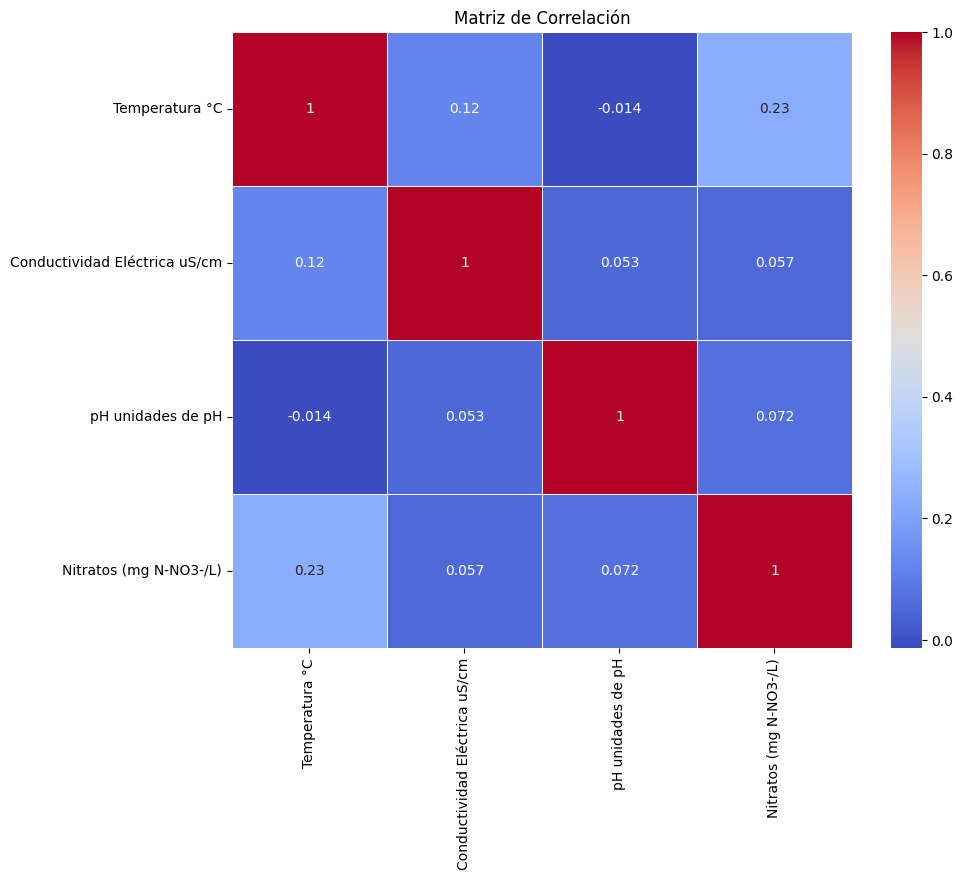

In [ ]:
# Calcular la matriz de correlación
corr_matrix = W.corr()

# Mostrar la matriz de correlación
print("Matriz de correlación:")
print(corr_matrix)

# Graficar la matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación')
plt.show()

In [ ]:
W.describe()

,Temperatura °C,Conductividad Eléctrica uS/cm,pH unidades de pH,Nitratos (mg N-NO3-/L)
count,166.000000,166.000000,166.000000,166.000000
mean,23.606627,113.544578,7.446446,0.289167
std,2.639356,84.383908,0.540610,0.148307
min,15.700000,23.900000,4.110000,0.028000
25%,21.700000,90.605000,7.272500,0.172500
50%,24.100000,109.000000,7.565000,0.294000
75%,25.275000,123.000000,7.710000,0.348825
max,32.300000,1122.000000,9.030000,1.200000


In [ ]:
columns_to_drop_1 = [2, 3, 6, 8, 9, 10]
P = df.drop(df.columns[columns_to_drop_1], axis=1)
Q = P.dropna()
print (Q)

                             Nombre punto de monitoreo fecha de monitoreo  \
0    RCA_MAGDALENA_HUI_GIGANTE_PASO DEL COLEGIO [21...         30/03/2009   
1    RCA_MAGDALENA_HUI_GIGANTE_PASO DEL COLEGIO [21...          4/06/2009   
2    RCA_MAGDALENA_HUI_GIGANTE_PASO DEL COLEGIO [21...         19/06/2009   
3    RCA_MAGDALENA_HUI_GIGANTE_PASO DEL COLEGIO [21...         11/09/2009   
4    RCA_MAGDALENA_HUI_GIGANTE_PASO DEL COLEGIO [21...         31/10/2009   
..                                                 ...                ...   
163   RCA_MAGDALENA_TOL_NATAGAIMA_ANGOSTURA [21137050]         15/10/2022   
164   RCA_MAGDALENA_TOL_NATAGAIMA_ANGOSTURA [21137050]         15/11/2022   
165   RCA_MAGDALENA_TOL_NATAGAIMA_ANGOSTURA [21137050]         28/07/2023   
166   RCA_MAGDALENA_TOL_NATAGAIMA_ANGOSTURA [21137050]         29/09/2023   
167   RCA_MAGDALENA_TOL_NATAGAIMA_ANGOSTURA [21137050]         12/11/2023   

     Temperatura °C  Conductividad Eléctrica uS/cm  pH unidades de pH  \
0 

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


/tmp/ipykernel_3325/3492346926.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  Q['Nitratos (mg N-NO3-/L)'].fillna(mean_values, inplace=True)
/tmp/ipykernel_3325/3492346926.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Q['Nitratos (mg N-NO3-/L)'].fillna(mean_values, inplace=True)


Mejores hiperparámetros para Random Forest: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 50}
Random Forest - Error cuadrático medio (MSE): 0.011600436430978717
Random Forest - Error Absoluto Medio (MAE): 0.0846491031419484
Random Forest - Coeficiente de determinación (R^2): -0.046114874049098864
Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Mejores hiperparámetros para Gradient Boosting: {'learning_rate': 0.01, 'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 50}
Gradient Boosting - Error cuadrático medio (MSE): 0.00954839002231415
Gradient Boosting - Error Absoluto Medio (MAE): 0.080612900928186
Gradient Boosting - Coeficiente de determinación (R^2): 0.13893646286529404
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Mejores hiperparámetros para XGBoost: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
XGBoos

/tmp/ipykernel_3325/3492346926.py:137: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, color='red')


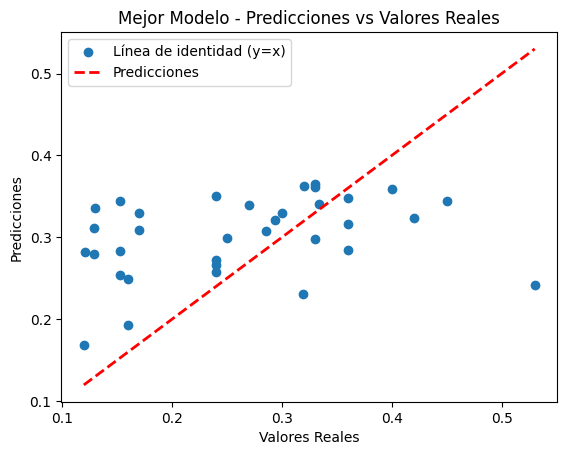

Puntajes R^2 de validación cruzada: [-2.09154612e-01 -2.57900626e+00  2.28249466e-03 -6.37871718e-02
 -1.29890139e-01]
Media de los puntajes R^2: -0.5959111380713953


In [ ]:
# Imputación de valores faltantes en Nitratos
mean_values = Q.groupby(['Nombre punto de monitoreo'])['Nitratos (mg N-NO3-/L)'].transform('mean')
Q['Nitratos (mg N-NO3-/L)'].fillna(mean_values, inplace=True)

if Q['Nitratos (mg N-NO3-/L)'].isna().sum() > 0:
    global_mean = Q['Nitratos (mg N-NO3-/L)'].mean()
    Q['Nitratos (mg N-NO3-/L)'].fillna(global_mean, inplace=True)

# Definir las características (X) y la etiqueta (y)
X = Q[['Temperatura °C', 'Conductividad Eléctrica uS/cm', 'pH unidades de pH']]
y = Q['Nitratos (mg N-NO3-/L)']

# Agregar características polinómicas
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# Normalizar las características
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

# Dividir los datos en conjunto de entrenamiento y conjunto de prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Definir el modelo Random Forest
rf_model = RandomForestRegressor(random_state=42)

# Definir la cuadrícula de hiperparámetros para Random Forest
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Configurar la búsqueda en cuadrícula para Random Forest
rf_grid_search = GridSearchCV(estimator=rf_model, param_grid=rf_param_grid, cv=5, n_jobs=-1, verbose=2, scoring='r2')

# Entrenar el modelo Random Forest
rf_grid_search.fit(X_train, y_train)

# Mejor conjunto de hiperparámetros para Random Forest
rf_best_params = rf_grid_search.best_params_
print("Mejores hiperparámetros para Random Forest:", rf_best_params)

# Evaluar el modelo Random Forest con los mejores hiperparámetros
rf_best_model = rf_grid_search.best_estimator_
rf_y_pred = rf_best_model.predict(X_test)

# Calcular el error cuadrático medio (MSE), el MAE y el coeficiente de determinación (R^2) para Random Forest
rf_mse = mean_squared_error(y_test, rf_y_pred)
rf_mae = mean_absolute_error(y_test, rf_y_pred)
rf_r2 = r2_score(y_test, rf_y_pred)

# Imprimir los resultados para Random Forest
print("Random Forest - Error cuadrático medio (MSE):", rf_mse)
print("Random Forest - Error Absoluto Medio (MAE):", rf_mae)
print("Random Forest - Coeficiente de determinación (R^2):", rf_r2)

# Definir el modelo Gradient Boosting
gb_model = GradientBoostingRegressor(random_state=42)

# Definir la cuadrícula de hiperparámetros para Gradient Boosting
gb_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Configurar la búsqueda en cuadrícula para Gradient Boosting
gb_grid_search = GridSearchCV(estimator=gb_model, param_grid=gb_param_grid, cv=5, n_jobs=-1, verbose=2, scoring='r2')

# Entrenar el modelo Gradient Boosting
gb_grid_search.fit(X_train, y_train)

# Mejor conjunto de hiperparámetros para Gradient Boosting
gb_best_params = gb_grid_search.best_params_
print("Mejores hiperparámetros para Gradient Boosting:", gb_best_params)

# Evaluar el modelo Gradient Boosting con los mejores hiperparámetros
gb_best_model = gb_grid_search.best_estimator_
gb_y_pred = gb_best_model.predict(X_test)

# Calcular el error cuadrático medio (MSE), el MAE y el coeficiente de determinación (R^2) para Gradient Boosting
gb_mse = mean_squared_error(y_test, gb_y_pred)
gb_mae = mean_absolute_error(y_test, gb_y_pred)
gb_r2 = r2_score(y_test, gb_y_pred)

# Imprimir los resultados para Gradient Boosting
print("Gradient Boosting - Error cuadrático medio (MSE):", gb_mse)
print("Gradient Boosting - Error Absoluto Medio (MAE):", gb_mae)
print("Gradient Boosting - Coeficiente de determinación (R^2):", gb_r2)

# Definir el modelo XGBoost
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Definir la cuadrícula de hiperparámetros para XGBoost
xgb_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# Configurar la búsqueda en cuadrícula para XGBoost
xgb_random_search = RandomizedSearchCV(estimator=xgb_model, param_distributions=xgb_param_grid, n_iter=50, cv=5, n_jobs=-1, verbose=2, scoring='r2')

# Entrenar el modelo XGBoost
xgb_random_search.fit(X_train, y_train)

# Mejor conjunto de hiperparámetros para XGBoost
xgb_best_params = xgb_random_search.best_params_
print("Mejores hiperparámetros para XGBoost:", xgb_best_params)

# Evaluar el modelo XGBoost con los mejores hiperparámetros
xgb_best_model = xgb_random_search.best_estimator_
xgb_y_pred = xgb_best_model.predict(X_test)

# Calcular el error cuadrático medio (MSE), el MAE y el coeficiente de determinación (R^2) para XGBoost
xgb_mse = mean_squared_error(y_test, xgb_y_pred)
xgb_mae = mean_absolute_error(y_test, xgb_y_pred)
xgb_r2 = r2_score(y_test, xgb_y_pred)

# Imprimir los resultados para XGBoost
print("XGBoost - Error cuadrático medio (MSE):", xgb_mse)
print("XGBoost - Error Absoluto Medio (MAE):", xgb_mae)
print("XGBoost - Coeficiente de determinación (R^2):", xgb_r2)

# Graficar las predicciones vs los valores reales para el mejor modelo (puedes elegir el que tenga mejor desempeño)
best_model = rf_best_model  # Cambia esto según el mejor modelo

y_pred = best_model.predict(X_test)
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, color='red')
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Mejor Modelo - Predicciones vs Valores Reales')
plt.legend(['Línea de identidad (y=x)', 'Predicciones'])
plt.show()

# Evaluar el mejor modelo usando validación cruzada
cv_scores = cross_val_score(best_model, X_scaled, y, cv=5, scoring='r2')
print("Puntajes R^2 de validación cruzada:", cv_scores)
print("Media de los puntajes R^2:", np.mean(cv_scores))

                                    Característica  Importancia
3                                 Temperatura °C^2     0.214356
0                                   Temperatura °C     0.138705
5                 Temperatura °C pH unidades de pH     0.114350
4     Temperatura °C Conductividad Eléctrica uS/cm     0.105514
7  Conductividad Eléctrica uS/cm pH unidades de pH     0.102939
1                    Conductividad Eléctrica uS/cm     0.090814
6                  Conductividad Eléctrica uS/cm^2     0.083763
8                              pH unidades de pH^2     0.075745
2                                pH unidades de pH     0.073815


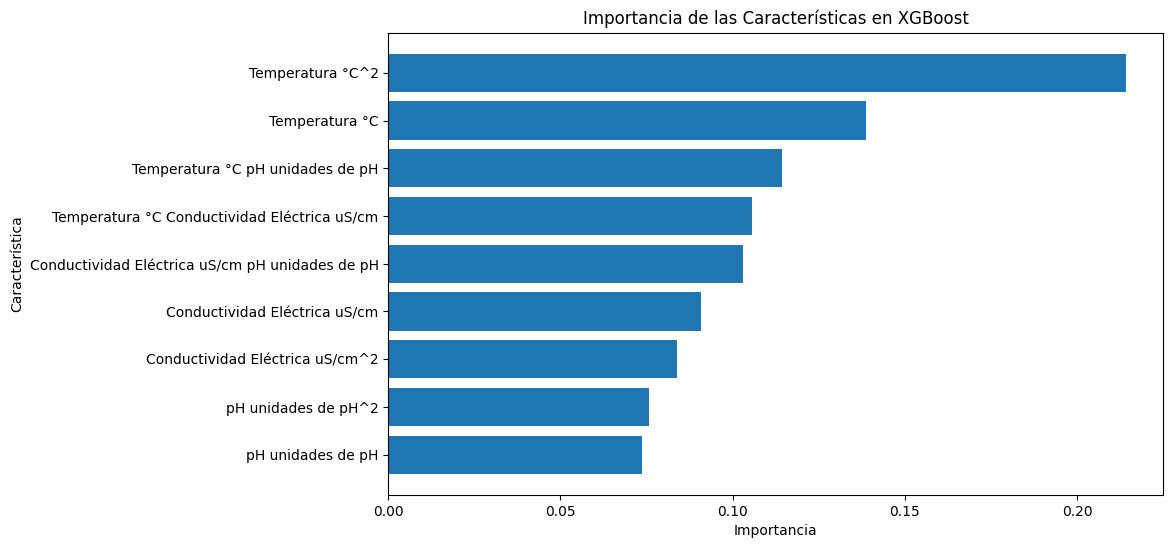

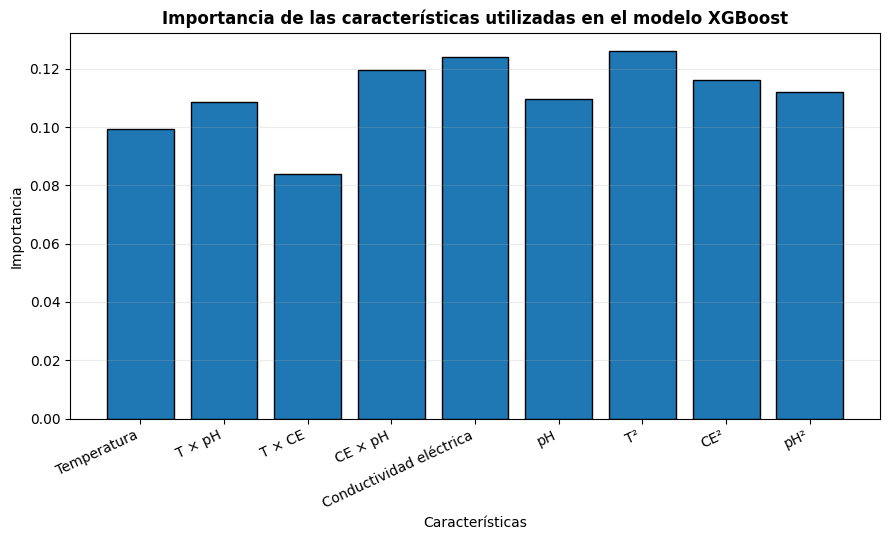

                                           feature            feature_clean  \
0                                   Temperatura °C              Temperatura   
5                 Temperatura °C pH unidades de pH                   T × pH   
4     Temperatura °C Conductividad Eléctrica uS/cm                   T × CE   
7  Conductividad Eléctrica uS/cm pH unidades de pH                  CE × pH   
1                    Conductividad Eléctrica uS/cm  Conductividad eléctrica   
2                                pH unidades de pH                       pH   
3                                 Temperatura °C^2                       T²   
6                  Conductividad Eléctrica uS/cm^2                      CE²   
8                              pH unidades de pH^2                      pH²   

   importance  
0    0.099483  
5    0.108589  
4    0.083980  
7    0.119572  
1    0.124232  
2    0.109812  
3    0.126055  
6    0.116115  
8    0.112163  


In [ ]:
# Obtener la importancia de las características del modelo XGBoost
feature_importances = xgb_best_model.feature_importances_

# Crear un DataFrame para organizar las importancias junto con el nombre de las características
features = poly.get_feature_names_out(input_features=X.columns)
feature_importance_df = pd.DataFrame({
    'Característica': features,
    'Importancia': feature_importances
})

# Ordenar por importancia
feature_importance_df = feature_importance_df.sort_values(by='Importancia', ascending=False)

# Imprimir la importancia de las características
print(feature_importance_df)

# Graficar la importancia de las características
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Característica'], feature_importance_df['Importancia'])
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.title('Importancia de las Características en XGBoost')
plt.gca().invert_yaxis()  # Invertir el eje y para que la característica más importante aparezca arriba
plt.show()

import re
import unicodedata
import pandas as pd
import matplotlib.pyplot as plt

# ====== AJUSTA SOLO ESTAS DOS SI TUS VARIABLES SE LLAMAN DISTINTO ======
poly_obj = poly
model_obj = rf_best_model
# ======================================================================

# 1) Detectar nombres de entrada del modelo polinómico
if hasattr(poly_obj, "feature_names_in_"):
    input_names = list(poly_obj.feature_names_in_)
elif "X_train" in globals() and hasattr(X_train, "columns"):
    input_names = list(X_train.columns)
elif "X" in globals() and hasattr(X, "columns"):
    input_names = list(X.columns)
else:
    input_names = [
        "Temperatura °C",
        "Conductividad Eléctrica uS/cm",
        "pH unidades de pH"
    ]

# Asegurar consistencia con el número de variables del PolynomialFeatures
n_features = getattr(poly_obj, "n_features_in_", len(input_names))
input_names = input_names[:n_features]

# 2) Obtener nombres de características e importancias
feature_names = poly_obj.get_feature_names_out(input_names)
importances = model_obj.feature_importances_

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

# 3) Función para limpiar texto
def norm_txt(s):
    s = str(s).strip().lower()
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")
    s = re.sub(r"[^a-z0-9]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

# 4) Convertir nombres técnicos a etiquetas académicas
def academic_label(name):
    s = norm_txt(name)

    # Interacciones
    if "temperatura" in s and "conductividad" in s:
        return "T × CE"
    if "temperatura" in s and "ph" in s:
        return "T × pH"
    if "conductividad" in s and "ph" in s:
        return "CE × pH"

    # Términos cuadráticos
    if "temperatura" in s and ("2" in s or "^2" in str(name)):
        return "T²"
    if "conductividad" in s and ("2" in s or "^2" in str(name)):
        return "CE²"
    if "ph" in s and ("2" in s or "^2" in str(name)):
        return "pH²"

    # Variables base
    if "temperatura" in s:
        return "Temperatura"
    if "conductividad" in s:
        return "Conductividad eléctrica"
    if "ph" in s:
        return "pH"

    return str(name)

feat_imp["feature_clean"] = feat_imp["feature"].apply(academic_label)

# 5) Orden deseado de aparición en la gráfica
orden_final = [
    "Temperatura",
    "T × pH",
    "T × CE",
    "CE × pH",
    "Conductividad eléctrica",
    "pH",
    "T²",
    "CE²",
    "pH²"
]

presentes = [x for x in orden_final if x in feat_imp["feature_clean"].tolist()]
restantes = [x for x in feat_imp["feature_clean"].tolist() if x not in presentes]
orden_total = presentes + restantes

feat_imp["feature_clean"] = pd.Categorical(
    feat_imp["feature_clean"],
    categories=orden_total,
    ordered=True
)

feat_imp = feat_imp.sort_values("feature_clean")

# 6) Gráfica final
plt.figure(figsize=(9, 5.5))
plt.bar(feat_imp["feature_clean"].astype(str), feat_imp["importance"], edgecolor="black")
plt.xlabel("Características")
plt.ylabel("Importancia")
plt.title("Importancia de las características utilizadas en el modelo XGBoost", fontsize=12, fontweight="bold")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig("fig_importancia_xgboost_etiquetas_academicas.png", dpi=300, bbox_inches="tight")
plt.show()

print(feat_imp[["feature", "feature_clean", "importance"]])

Usando DataFrame: df
Columnas seleccionadas:
Temperatura -> temperatura_c
CE -> conductividad_electrica_us_cm
pH -> ph_unidades_de_ph
Nitratos -> nitrogeno_total_mg_l
Registros usados: 164
   Temperatura  Conductividad eléctrica    pH  Nitratos
0         22.0                    128.0  7.84      1.00
1         21.4                    102.0  7.76      0.53
2         24.1                    120.3  6.61      0.61
3         23.5                    111.0  7.37      0.50
4         25.5                    199.0  7.19      3.50


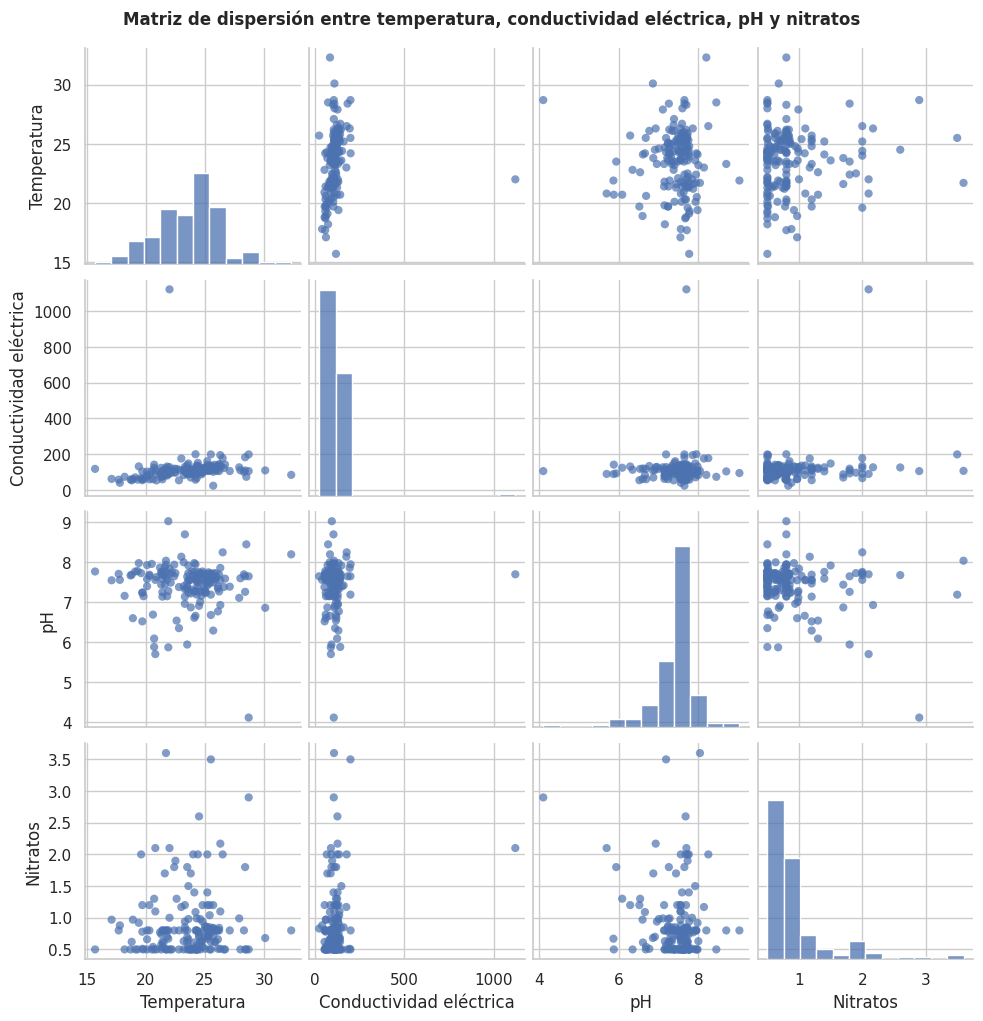

Archivo generado: fig_pairplot_variables_nitratos.png


In [ ]:
import re
import unicodedata
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# PAIRPLOT / MATRIZ DE DISPERSIÓN
# Busca automáticamente:
# - temperatura
# - conductividad eléctrica
# - pH
# - nitratos
# en un DataFrame ya cargado en el notebook
# ============================================================

# 1) Buscar un DataFrame disponible
df_base = None
for name in ["df_model", "df", "data", "dataset", "datos", "train_df"]:
    if name in globals() and isinstance(globals()[name], pd.DataFrame):
        df_base = globals()[name].copy()
        print("Usando DataFrame:", name)
        break

if df_base is None:
    raise RuntimeError("No encontré un DataFrame cargado en el notebook.")

# 2) Normalizar nombres de columnas
def norm_col(s):
    s = str(s).strip().lower()
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")
    s = re.sub(r"[^a-z0-9]+", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s

original_cols = list(df_base.columns)
df_base.columns = [norm_col(c) for c in df_base.columns]
cols = df_base.columns.tolist()

# 3) Buscar columnas
def find_col(posibles):
    for p in posibles:
        p = norm_col(p)
        if p in cols:
            return p

    for c in cols:
        for p in posibles:
            p = norm_col(p)
            if p in c:
                return c

    return None

col_temp = find_col([
    "temperatura",
    "temperatura_c",
    "temp",
    "temp_c"
])

col_ce = find_col([
    "conductividad_electrica",
    "conductividad",
    "ce",
    "ce_agua",
    "conductividad_electrica_us_cm",
    "conductividad_electrica_uS_cm"
])

col_ph = find_col([
    "ph",
    "ph_agua",
    "ph_unidades_de_ph"
])

col_n = find_col([
    "nitratos",
    "nitrogeno",
    "nitrogeno_agua_mg_l",
    "n_agua_no3n",
    "n_agua",
    "no3n_mg_l",
    "nitrato"
])

if not all([col_temp, col_ce, col_ph, col_n]):
    print("Columnas detectadas:")
    for c in cols:
        print("-", c)
    raise RuntimeError(
        f"No pude detectar todas las columnas.\n"
        f"Temperatura = {col_temp}\n"
        f"CE = {col_ce}\n"
        f"pH = {col_ph}\n"
        f"Nitratos = {col_n}"
    )

print("Columnas seleccionadas:")
print("Temperatura ->", col_temp)
print("CE ->", col_ce)
print("pH ->", col_ph)
print("Nitratos ->", col_n)

# 4) Construir DataFrame limpio
pair_df = df_base[[col_temp, col_ce, col_ph, col_n]].copy()
pair_df.columns = [
    "Temperatura",
    "Conductividad eléctrica",
    "pH",
    "Nitratos"
]

for c in pair_df.columns:
    pair_df[c] = pd.to_numeric(pair_df[c], errors="coerce")

pair_df = pair_df.dropna().reset_index(drop=True)

print("Registros usados:", pair_df.shape[0])
print(pair_df.head())

# 5) Graficar pairplot
sns.set(style="whitegrid", context="notebook")

g = sns.pairplot(
    pair_df,
    diag_kind="hist",
    plot_kws={"alpha": 0.7, "s": 35, "edgecolor": "none"},
    diag_kws={"bins": 12}
)

g.fig.suptitle(
    "Matriz de dispersión entre temperatura, conductividad eléctrica, pH y nitratos",
    y=1.02,
    fontsize=12,
    fontweight="bold"
)

g.fig.savefig("fig_pairplot_variables_nitratos.png", dpi=300, bbox_inches="tight")
plt.show()

print("Archivo generado: fig_pairplot_variables_nitratos.png")

                                           feature            feature_clean  \
7  Conductividad Eléctrica uS/cm pH unidades de pH                  CE × pH   
1                    Conductividad Eléctrica uS/cm  Conductividad eléctrica   
5                 Temperatura °C pH unidades de pH                   T × pH   
3                                 Temperatura °C^2                       T²   
0                                   Temperatura °C              Temperatura   
6                  Conductividad Eléctrica uS/cm^2                      CE²   
4     Temperatura °C Conductividad Eléctrica uS/cm                   T × CE   
2                                pH unidades de pH                       pH   
8                              pH unidades de pH^2                      pH²   

   mean_abs_shap  
7       0.035107  
1       0.033461  
5       0.028228  
3       0.014087  
0       0.013843  
6       0.013229  
4       0.009718  
2       0.008175  
8       0.000469  


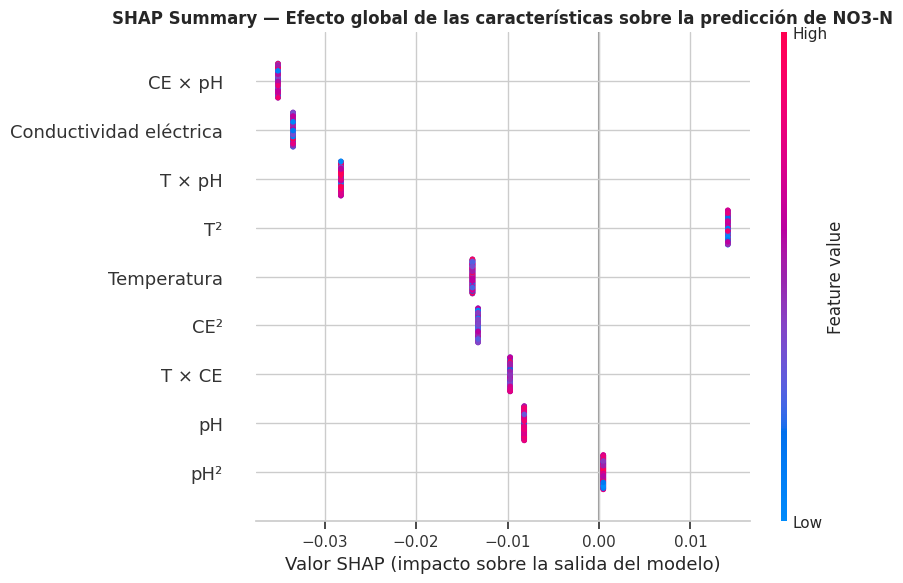

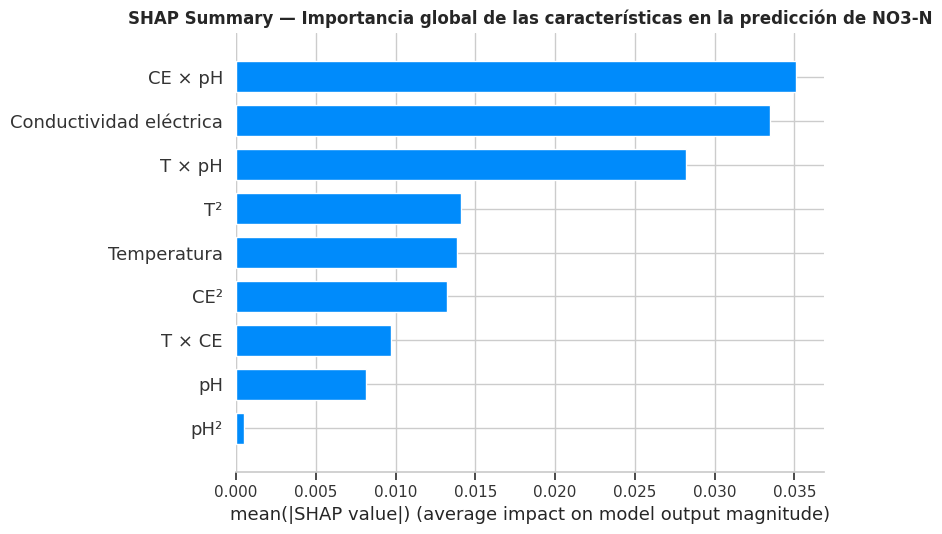


Archivos generados:
- fig_shap_summary_beeswarm.png
- fig_shap_summary_bar.png


In [ ]:
import re
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

# ============================================================
# SHAP para el modelo final de la tesis
# Funciona aunque X_train/X sea DataFrame o numpy array
# Requiere que ya existan en memoria:
#   - poly
#   - best_xgb o modelo
# Opcional:
#   - scaler
#   - X_train o X
# ============================================================

# -------------------------------
# 1) Detectar objetos
# -------------------------------
poly_obj = None
for name in ["poly", "poly_features", "polynomial_features", "pf"]:
    if name in globals():
        poly_obj = globals()[name]
        break

if poly_obj is None:
    raise RuntimeError("No encontré el objeto PolynomialFeatures (poly).")

model_obj = None
for name in ["best_xgb", "modelo", "xgb_model", "model", "best_model"]:
    if name in globals():
        obj = globals()[name]
        if hasattr(obj, "predict") and hasattr(obj, "feature_importances_"):
            model_obj = obj
            break

if model_obj is None:
    raise RuntimeError("No encontré el modelo XGBoost entrenado.")

scaler_obj = None
for name in ["scaler", "scaler_nitratos", "scaler_obj"]:
    if name in globals():
        scaler_obj = globals()[name]
        break

X_source = None
for name in ["X_train", "X", "X_model"]:
    if name in globals():
        X_source = globals()[name]
        break

if X_source is None:
    raise RuntimeError("No encontré X_train, X ni X_model en memoria.")

# -------------------------------
# 2) Nombres base de variables
# -------------------------------
n_input = getattr(poly_obj, "n_features_in_", None)

if hasattr(poly_obj, "feature_names_in_"):
    input_names = list(poly_obj.feature_names_in_)
elif isinstance(X_source, pd.DataFrame):
    input_names = list(X_source.columns[:n_input])
else:
    if n_input == 3:
        input_names = [
            "Temperatura °C",
            "Conductividad Eléctrica uS/cm",
            "pH unidades de pH"
        ]
    else:
        input_names = [f"x{i+1}" for i in range(n_input)]

# -------------------------------
# 3) Preparar X_base
# -------------------------------
if isinstance(X_source, pd.DataFrame):
    X_df = X_source.copy()
else:
    X_arr = np.asarray(X_source)
    if X_arr.ndim != 2:
        raise RuntimeError("X_train/X debe ser una matriz 2D.")
    X_df = pd.DataFrame(X_arr)

# Si X_source tiene exactamente las variables base
if X_df.shape[1] == n_input:
    X_base = X_df.copy()
    X_base.columns = input_names
    feature_names_poly = poly_obj.get_feature_names_out(input_names)
    X_poly = poly_obj.transform(X_base)

# Si X_source ya viene expandido con PolynomialFeatures
else:
    feature_names_poly = poly_obj.get_feature_names_out(input_names)
    n_poly = len(feature_names_poly)

    if X_df.shape[1] == n_poly:
        X_poly = np.asarray(X_df)
    else:
        raise RuntimeError(
            f"El número de columnas de X ({X_df.shape[1]}) no coincide "
            f"ni con las variables base ({n_input}) ni con las variables polinómicas ({n_poly})."
        )

# Aplicar scaler si existe
if scaler_obj is not None:
    X_model = scaler_obj.transform(X_poly)
else:
    X_model = X_poly

X_model_df = pd.DataFrame(X_model, columns=feature_names_poly)

# -------------------------------
# 4) Etiquetas académicas
# -------------------------------
def norm_txt(s):
    s = str(s).strip().lower()
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")
    s = re.sub(r"[^a-z0-9]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def academic_label(name):
    s = norm_txt(name)

    if "temperatura" in s and "conductividad" in s:
        return "T × CE"
    if "temperatura" in s and "ph" in s:
        return "T × pH"
    if "conductividad" in s and "ph" in s:
        return "CE × pH"

    if "temperatura" in s and ("2" in s or "^2" in str(name)):
        return "T²"
    if "conductividad" in s and ("2" in s or "^2" in str(name)):
        return "CE²"
    if "ph" in s and ("2" in s or "^2" in str(name)):
        return "pH²"

    if "temperatura" in s or s == "x1":
        return "Temperatura"
    if "conductividad" in s or s == "x2":
        return "Conductividad eléctrica"
    if "ph" in s or s == "x3":
        return "pH"

    return str(name)

feature_names_clean = [academic_label(f) for f in feature_names_poly]

# -------------------------------
# 5) Calcular SHAP
# -------------------------------
explainer = shap.TreeExplainer(model_obj)
shap_values = explainer.shap_values(X_model_df)

if isinstance(shap_values, list):
    shap_values = shap_values[0]

# -------------------------------
# 6) Tabla de importancia SHAP
# -------------------------------
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_table = pd.DataFrame({
    "feature": feature_names_poly,
    "feature_clean": feature_names_clean,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False)

print(shap_table)

# -------------------------------
# 7) Beeswarm SHAP
# -------------------------------
plt.figure(figsize=(9, 6))
shap.summary_plot(
    shap_values,
    features=X_model_df,
    feature_names=feature_names_clean,
    show=False,
    plot_size=None
)
plt.title(
    "SHAP Summary — Efecto global de las características sobre la predicción de NO3-N",
    fontsize=12,
    fontweight="bold"
)
plt.xlabel("Valor SHAP (impacto sobre la salida del modelo)")
plt.tight_layout()
plt.savefig("fig_shap_summary_beeswarm.png", dpi=300, bbox_inches="tight")
plt.show()

# -------------------------------
# 8) SHAP bar
# -------------------------------
plt.figure(figsize=(8.5, 5.5))
shap.summary_plot(
    shap_values,
    features=X_model_df,
    feature_names=feature_names_clean,
    plot_type="bar",
    show=False,
    plot_size=None
)
plt.title(
    "SHAP Summary — Importancia global de las características en la predicción de NO3-N",
    fontsize=12,
    fontweight="bold"
)
plt.tight_layout()
plt.savefig("fig_shap_summary_bar.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nArchivos generados:")
print("- fig_shap_summary_beeswarm.png")
print("- fig_shap_summary_bar.png")